## Setup

### Import Libraries

In [28]:
import os
from tqdm import tqdm
import sys

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import random_split

from pathlib import Path
import xarray as xr

from models.Unet import Unet


### Set Seed

In [13]:
SEED = 2025
torch.manual_seed(SEED)

### Set Data Path

In [7]:
data_dir = Path('data')
data_dir.mkdir(exist_ok=True, parents=True)

### Download Data

In [ ]:
import owncloud
owncloud.Client.from_public_link('https://uni-bonn.sciebo.de/s/brt3t6FKkwnoTG3').get_file('/', data_dir / 'cells_data_all.nc')

True

## Section 1: Build a Convolutional Neural Network

| Code | Description |
| --- | --- |
| `nn.Conv2d(in_channels, out_channels, kernel_size)` | Creates a 2D convolution to be applied to the signal. |

**Example**: Create a 2D convolution object with 9 in channels, 3 out channels, and a 3x3 kernel.

In [2]:
nn.Conv2d(9, 3, (3,3))

Conv2d(9, 3, kernel_size=(3, 3), stride=(1, 1))

**Exercise**: Create a 2D convolution object with 8 in channels, 2 out channels, and a 2x2 kernel.

In [3]:
nn.Conv2d(8,2,(2,2))

Conv2d(8, 2, kernel_size=(2, 2), stride=(1, 1))

## Section 2: Apply CNN to Data

## Section 3: Use an Advanced CNN Model for Cellular Segmentation

In [8]:
class CellsDataset(Dataset):
    def __init__(self) -> None:
        super(CellsDataset, self).__init__()

        # load dataset
        dataset = xr.load_dataset(data_dir / 'cells_data_all.nc')

        # extract images and labels from dataset
        self.images = torch.from_numpy(dataset['ca_image_data'].values).float()
        self.labels = torch.from_numpy(dataset['cell_labels'].values).float()

    def __len__(self):
        """Get the number of images in dataset"""
        return len(self.images)

    def __getitem__(self, index):
        """Get a specific image and its cell labels"""
        return self.images[index], self.labels[index]

Load cell data class

In [9]:
cells_data = CellsDataset()

Split data into train, validation, and test sets

In [12]:
train_proportion = 0.7
val_proportion = 0.15
test_proportion = 1-0.7-0.15

train_data, val_data, test_data = random_split(cells_data, [train_proportion, val_proportion, test_proportion])

Visualize example image from training data

In [21]:
train_data[0][0].shape

torch.Size([2, 392, 520])

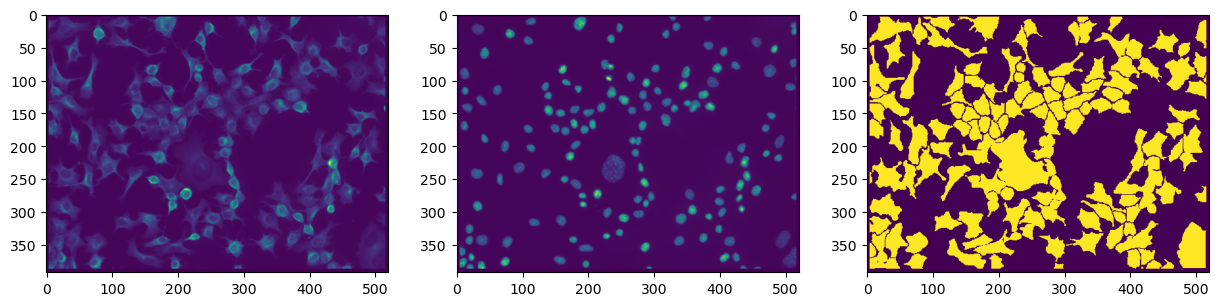

In [25]:
train_image, train_label = train_data[0]

fig, axes = plt.subplots(ncols=3, figsize = (15,6))

axes[0].imshow(train_image[0])
axes[1].imshow(train_image[1])
axes[2].imshow(train_label);

Create DataLoader for each dataset

In [26]:
train_dataloader = DataLoader(train_data, shuffle=True, batch_size=8)
val_dataloader = DataLoader(val_data, shuffle=True, batch_size=8)
test_dataloader = DataLoader(test_data, shuffle=True, batch_size=len(test_data))

#### Define Model

In [29]:
kernel_size = 3
nbase = [2, 32, 64, 128, 256]  # number of channels per layer
nout = 2  # number of outputs

model = Unet(nbase, nout, kernel_size)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device);

Train model

In [ ]:
def train_model(model, dataloader, optimizer, loss_function = nn.CrossEntropyLoss(), device='cpu'):

    model.train()
    train_losses = 0
    #batch_accuracy = [] I'm not sure if I can calculate the accuracy during training because of gradients (with torch.no_grad()), that might be why they are splitting it up
    for batch_idx, (images, labels) in tqdm(enumerate(dataloader), desc='batch'):
        # Move data to the specified device
        images = images.to(device)
        labels = labels.to(device)

        #batch_accuracy.append(np.mean((labels == pred_labels).sum(axis=(1,2)) / labels[0].size))

        optimizer.zero_grad()

        output = model(images)

        loss = loss_function(output[:,0], labels)

        train_losses += (loss.item())

        loss.backward()

        optimizer.step()

    #train_accuracy = np.mean(batch_accuracy)
    train_losses /= len(dataloader)

    #print(f'Train accuracy {train_accuracy}')
    print(f'Train losses {train_losses}')

    return model, train_losses#, train_accuracy

def test_model(model, dataloader, loss_function = nn.CrossEntropyLoss(), device='cpu'):

    model.eval()
    with torch.no_grad():
        batch_accuracy = []
        loss = 0
        for batch_idx, (images, labels) in tqdm(enumerate(dataloader), desc='batch'):

            # Move data to the specified device
            images = images.to(device)
            labels = labels.to(device)

            output = model(images)

            loss += loss_function(output[:,0], labels).item()

            pred_labels = output[:,0].detach().cpu().numpy() > 0.5 # Move back to CPU for numpy conversion
            labels_acc = labels.detach().cpu().numpy() # Move back to CPU for numpy conversion

            batch_accuracy.append(np.mean((labels_acc == pred_labels).sum(axis=(1,2)) / labels_acc[0].size))

            print(f'Batch: {batch_idx}, loss: {loss_function(output[:,0], labels).item()}, batch accuracy: {batch_accuracy[-1]}')

        accuracy = np.mean(batch_accuracy)
        loss /= len(dataloader)

    return accuracy, loss

Train model

In [ ]:
train_losses_lr, train_accuracies_lr = [], []
val_losses_lr, val_accuracies_lr = [], []

for learning_rate in [0.01]:

  model = Unet(nbase, nout, kernel_size)

  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  model.to(device);

  nepochs = 7

  model.train()
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

  loss_function = nn.CrossEntropyLoss()

  train_losses, train_accuracies = [], []
  val_losses, val_accuracies = [], []
  for epoch in range(nepochs):

      model, train_loss = train_model(model, train_dataloader, optimizer, device=device)

      train_accuracy, train_loss = test_model(model, train_dataloader, device=device)
      val_accuracy, val_loss = test_model(model, val_dataloader, device=device)

      train_losses.append(train_loss)
      train_accuracies.append(train_accuracy)

      val_losses.append(val_loss)
      val_accuracies.append(val_accuracy)

  train_losses_lr.append(train_losses)
  train_accuracies_lr.append(train_accuracies)

  val_losses_lr.append(val_losses)
  val_accuracies_lr.append(val_accuracies)

Test model

In [ ]:
from numpy._core.numeric import astype
model.eval()

with torch.no_grad():
  for val_images, val_labels in val_dataloader:
    test_images, test_labels = next(iter(test_dataloader))

    # Move data to the specified device
    val_images = val_images.to(device)
    val_labels = val_labels.to(device)

    output = model(val_images)

    pred_labels = (output[:,0].detach().cpu().numpy() > 0.5).astype(int)

    val_accuracy = (val_labels.cpu().detach().numpy() == pred_labels).sum(axis=(1,2)) / val_labels.cpu().detach().numpy()[0].size
    print(val_accuracy.mean())


In [ ]:
fig, axes = plt.subplots(ncols = 2, figsize = (8,12))

val_labels_plot = val_labels.cpu().detach().numpy()

image_nr = 4
axes[0].imshow(val_labels_plot[image_nr])
axes[1].imshow(pred_labels[image_nr])

fig.tight_layout()